# 04 - Advanced Analytics

**Input:** `data/processed/transactions_parquet`


## 1. Setup & Data Loading

In [24]:
%matplotlib inline
from pathlib import Path
import sys, math, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

cwd = Path.cwd()
project_root = cwd if (cwd / 'src').exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pyspark.sql import functions as F, Window
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator
)
from src.pipeline import create_spark_session

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FRAUD_PALETTE = {0: '#4C9BE8', 1: '#E84C4C'}
FIG_DIR = project_root / 'notebooks' / 'eda_figures'
FIG_DIR.mkdir(exist_ok=True)

spark = create_spark_session(app_name='CreditCardAdvancedAnalytics')
raw_df = spark.read.parquet(str(project_root / 'data' / 'processed' / 'transactions_parquet'))
print(f'Loaded {raw_df.count():,} rows  |  {len(raw_df.columns)} columns')

Loaded 1,296,675 rows  |  23 columns


## 2. Feature Engineering for ML

Build all derived features needed across sections:
temporal, log-amount, haversine distance, cardholder age, gender encoding, card velocity, and category index.

In [25]:
@F.udf(returnType=DoubleType())
def haversine_km(lat1, lon1, lat2, lon2):
    if any(v is None for v in [lat1, lon1, lat2, lon2]):
        return None
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

df = raw_df \
    .withColumn('tx_hour',       F.hour('transaction_ts')) \
    .withColumn('tx_dow',        F.dayofweek('transaction_ts')) \
    .withColumn('tx_month',      F.month('transaction_ts')) \
    .withColumn('tx_is_weekend', (F.dayofweek('transaction_ts').isin(1, 7)).cast('int')) \
    .withColumn('amount_log1p',  F.log1p(F.col('amount'))) \
    .withColumn('merch_dist_km', haversine_km('lat', 'long', 'merch_lat', 'merch_long')) \
    .withColumn('age', F.floor(
        F.datediff(F.col('transaction_ts').cast('date'),
                   F.to_date(F.col('dob'), 'yyyy-MM-dd')) / 365.25
    )) \
    .withColumn('gender_bin', F.when(F.upper(F.col('gender')) == 'M', 1).otherwise(0).cast('int'))

# 1-hour rolling velocity per card
df = df.withColumn('tx_unix', F.unix_timestamp('transaction_ts'))
w_vel = Window.partitionBy('card_id').orderBy('tx_unix').rangeBetween(-3600, -1)
df = df.withColumn('card_tx_count_1h',  F.count('transaction_id').over(w_vel)) \
       .withColumn('card_amount_sum_1h', F.sum('amount').over(w_vel))

# Category numeric index
cat_indexer = StringIndexer(inputCol='category', outputCol='category_idx', handleInvalid='keep')
cat_model   = cat_indexer.fit(df)
df = cat_model.transform(df)

df.cache()
print(f'Feature-engineered rows: {df.count():,}')
df.select('amount', 'tx_hour', 'age', 'merch_dist_km', 'card_tx_count_1h',
          'category_idx', 'gender_bin', 'is_fraud').show(5)

Feature-engineered rows: 1,296,675
+------+-------+---+------------------+----------------+------------+----------+--------+
|amount|tx_hour|age|     merch_dist_km|card_tx_count_1h|category_idx|gender_bin|is_fraud|
+------+-------+---+------------------+----------------+------------+----------+--------+
|317.62|      3| 18|57.572233924691325|               0|         1.0|         1|       1|
|316.88|      4| 18| 49.73912343129139|               0|         1.0|         1|       1|
|980.77|     17| 18| 95.96362384456165|               0|         5.0|         1|       1|
| 15.68|     23| 18| 67.86213809856936|               0|         4.0|         1|       1|
| 10.64|      0| 18|32.599052993255526|               0|         0.0|         1|       1|
+------+-------+---+------------------+----------------+------------+----------+--------+
only showing top 5 rows



## 3. Fraud Detection (Binary Classification)

Train three classifiers on the highly imbalanced fraud labels.  
Class imbalance is handled via per-class weights derived from label frequency.  
Models: **Logistic Regression**, **Random Forest**, **Gradient Boosted Trees**.

In [26]:
FRAUD_FEATURES = [
    'amount', 'amount_log1p',
    'tx_hour', 'tx_dow', 'tx_month', 'tx_is_weekend',
    'city_pop', 'age', 'merch_dist_km',
    'card_tx_count_1h', 'card_amount_sum_1h',
    'gender_bin', 'category_idx'
]

# Impute nulls (age, merch_dist_km can be null)
imputer = Imputer(inputCols=FRAUD_FEATURES, outputCols=FRAUD_FEATURES, strategy='median')
imputed_df = imputer.fit(df).transform(df)

# Class weights to counter imbalance (weight = total / (2 * class_count))
counts = imputed_df.groupBy('is_fraud').count().collect()
total  = sum(r['count'] for r in counts)
weight_map = {r['is_fraud']: total / (2.0 * r['count']) for r in counts}
print('Class weights:', weight_map)

weight_udf = F.udf(lambda label: float(weight_map[label]), DoubleType())
imputed_df = imputed_df.withColumn('class_weight', weight_udf(F.col('is_fraud')))

# Assemble feature vector
assembler = VectorAssembler(inputCols=FRAUD_FEATURES, outputCol='features')
assembled = assembler.transform(imputed_df)

# 80/20 stratified-like split: split fraud and legit separately, then union
fraud_df = assembled.filter(F.col('is_fraud') == 1)
legit_df = assembled.filter(F.col('is_fraud') == 0)
fraud_train, fraud_test = fraud_df.randomSplit([0.8, 0.2], seed=42)
legit_train, legit_test = legit_df.randomSplit([0.8, 0.2], seed=42)
train_df = fraud_train.union(legit_train)
test_df  = fraud_test.union(legit_test)

print(f'Train: {train_df.count():,}  |  Test: {test_df.count():,}')
print(f'Train fraud: {fraud_train.count():,}  |  Test fraud: {fraud_test.count():,}')

Class weights: {1: 86.37589928057554, 0: 0.5029111776656126}


Train: 1,037,813  |  Test: 258,862


Train fraud: 5,960  |  Test fraud: 1,546


In [27]:
# --- Logistic Regression ---
lr = LogisticRegression(
    featuresCol='features', labelCol='is_fraud',
    weightCol='class_weight', maxIter=20, regParam=0.01
)
lr_model = lr.fit(train_df)
lr_preds = lr_model.transform(test_df)

bin_eval  = BinaryClassificationEvaluator(labelCol='is_fraud', metricName='areaUnderROC')
pr_eval   = BinaryClassificationEvaluator(labelCol='is_fraud', metricName='areaUnderPR')
mc_eval_f1 = MulticlassClassificationEvaluator(labelCol='is_fraud', predictionCol='prediction',
                                                metricName='f1')

lr_roc = bin_eval.evaluate(lr_preds)
lr_pr  = pr_eval.evaluate(lr_preds)
lr_f1  = mc_eval_f1.evaluate(lr_preds)
print(f'Logistic Regression  |  AUC-ROC: {lr_roc:.4f}  |  AUC-PR: {lr_pr:.4f}  |  F1: {lr_f1:.4f}')

Logistic Regression  |  AUC-ROC: 0.8908  |  AUC-PR: 0.2890  |  F1: 0.9719


In [28]:
# --- Random Forest ---
rf = RandomForestClassifier(
    featuresCol='features', labelCol='is_fraud',
    weightCol='class_weight',
    numTrees=100, maxDepth=8, seed=42
)
rf_model = rf.fit(train_df)
rf_preds = rf_model.transform(test_df)

rf_roc = bin_eval.evaluate(rf_preds)
rf_pr  = pr_eval.evaluate(rf_preds)
rf_f1  = mc_eval_f1.evaluate(rf_preds)
print(f'Random Forest        |  AUC-ROC: {rf_roc:.4f}  |  AUC-PR: {rf_pr:.4f}  |  F1: {rf_f1:.4f}')

26/04/28 10:53:04 WARN MemoryStore: Not enough space to cache rdd_402_241 in memory! (computed 5.4 MiB so far)
26/04/28 10:53:04 WARN MemoryStore: Not enough space to cache rdd_402_247 in memory! (computed 2.4 MiB so far)
26/04/28 10:53:04 WARN MemoryStore: Not enough space to cache rdd_402_248 in memory! (computed 2.4 MiB so far)
26/04/28 10:53:04 WARN MemoryStore: Not enough space to cache rdd_402_249 in memory! (computed 1033.4 KiB so far)
26/04/28 10:53:04 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_402_251 in memory.
26/04/28 10:53:04 WARN MemoryStore: Not enough space to cache rdd_402_251 in memory! (computed 384.0 B so far)
26/04/28 10:53:04 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_402_253 in memory.
26/04/28 10:53:04 WARN MemoryStore: Not enough space to cache rdd_402_253 in memory! (computed 384.0 B so far)
26/04/28 10:53:04 WARN MemoryStore: Failed to reserve initi

Random Forest        |  AUC-ROC: 0.9930  |  AUC-PR: 0.8305  |  F1: 0.9871


In [29]:
# --- Gradient Boosted Trees ---
gbt = GBTClassifier(
    featuresCol='features', labelCol='is_fraud',
    weightCol='class_weight',
    maxIter=50, maxDepth=5, seed=42
)
gbt_model = gbt.fit(train_df)
gbt_preds = gbt_model.transform(test_df)

gbt_roc = bin_eval.evaluate(gbt_preds)
gbt_pr  = pr_eval.evaluate(gbt_preds)
gbt_f1  = mc_eval_f1.evaluate(gbt_preds)
print(f'Gradient Boosted Trees|  AUC-ROC: {gbt_roc:.4f}  |  AUC-PR: {gbt_pr:.4f}  |  F1: {gbt_f1:.4f}')

Gradient Boosted Trees|  AUC-ROC: 0.9966  |  AUC-PR: 0.8683  |  F1: 0.9853


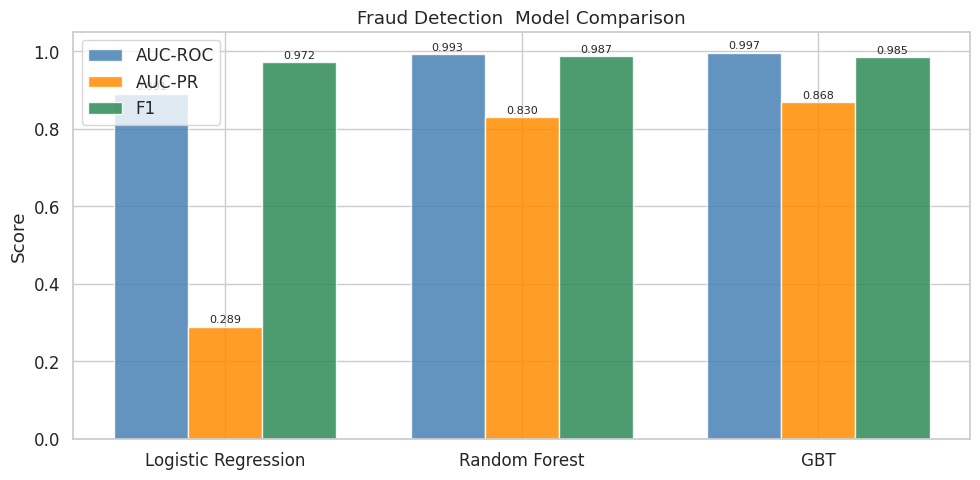

Saved: fraud_model_comparison.png


In [30]:
# --- Model Comparison Chart ---
models      = ['Logistic Regression', 'Random Forest', 'GBT']
roc_scores  = [lr_roc, rf_roc, gbt_roc]
pr_scores   = [lr_pr,  rf_pr,  gbt_pr]
f1_scores   = [lr_f1,  rf_f1,  gbt_f1]

x = np.arange(len(models))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, roc_scores, w, label='AUC-ROC', color='steelblue', alpha=0.85)
ax.bar(x,     pr_scores,  w, label='AUC-PR',  color='darkorange', alpha=0.85)
ax.bar(x + w, f1_scores,  w, label='F1',      color='seagreen',   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Fraud Detection  Model Comparison')
ax.legend()
for i, (r, p, f) in enumerate(zip(roc_scores, pr_scores, f1_scores)):
    ax.text(i - w, r + 0.01, f'{r:.3f}', ha='center', fontsize=8)
    ax.text(i,     p + 0.01, f'{p:.3f}', ha='center', fontsize=8)
    ax.text(i + w, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fraud_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fraud_model_comparison.png')

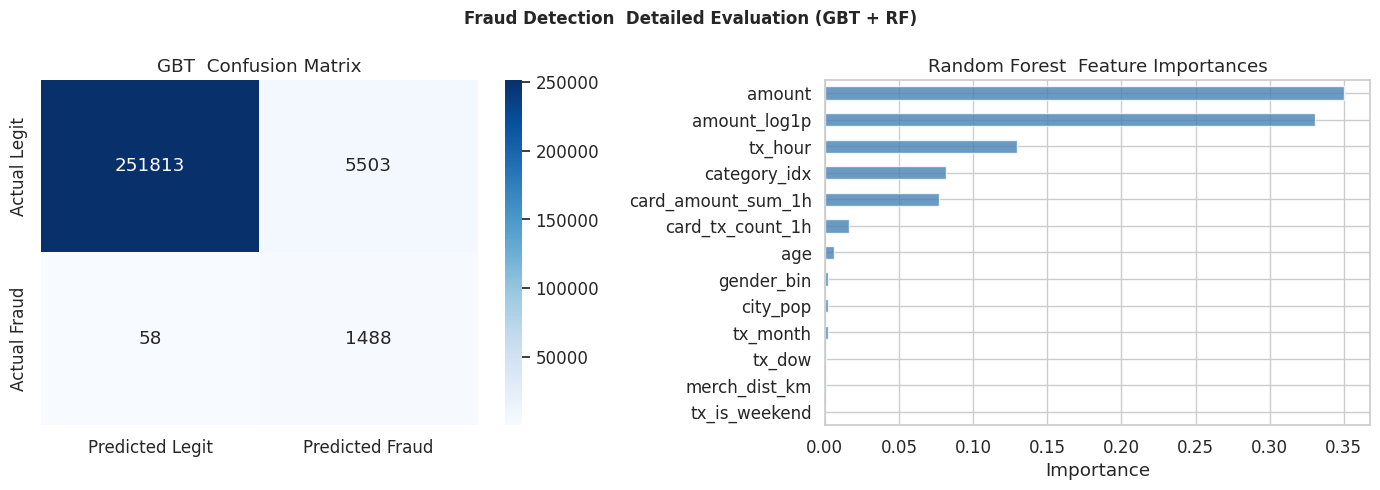


--- Classification Report (GBT) ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    257316
       Fraud       0.21      0.96      0.35      1546

    accuracy                           0.98    258862
   macro avg       0.61      0.97      0.67    258862
weighted avg       1.00      0.98      0.99    258862



In [31]:
from sklearn.metrics import confusion_matrix, classification_report

# Use best model (GBT) for detailed evaluation
pred_pd = gbt_preds.select('is_fraud', 'prediction').toPandas()
cm = confusion_matrix(pred_pd['is_fraud'], pred_pd['prediction'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
axes[0].set_title('GBT  Confusion Matrix')

# Feature importance from RF
fi = pd.Series(rf_model.featureImportances.toArray(), index=FRAUD_FEATURES) \
       .sort_values(ascending=True)
fi.plot(kind='barh', color='steelblue', alpha=0.8, ax=axes[1])
axes[1].set_xlabel('Importance')
axes[1].set_title('Random Forest  Feature Importances')

plt.suptitle('Fraud Detection  Detailed Evaluation (GBT + RF)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fraud_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Classification Report (GBT) ---')
print(classification_report(pred_pd['is_fraud'], pred_pd['prediction'],
                             target_names=['Legitimate', 'Fraud']))

## 4. Anomaly Detection

Identify unusual transactions using:
- **IQR & Z-Score**: statistical threshold-based outlier flagging on amount
- **High-Velocity Cards**: cards with abnormally high transaction frequency
- **Isolation Forest**: unsupervised ML outlier detection (scikit-learn on sample)

In [32]:
# IQR-based outlier detection
q1, q3 = df.select(
    F.percentile_approx('amount', 0.25).alias('q1'),
    F.percentile_approx('amount', 0.75).alias('q3')
).collect()[0]
iqr          = q3 - q1
iqr_upper    = q3 + 1.5 * iqr
iqr_outliers = df.filter(F.col('amount') > iqr_upper)

# Z-score outlier detection (|z| > 3)
stats = df.select(F.mean('amount').alias('mu'), F.stddev('amount').alias('sigma')).first()
df = df.withColumn('amount_zscore',
    ((F.col('amount') - stats['mu']) / stats['sigma']).cast(DoubleType())
)
zscore_outliers = df.filter(F.abs(F.col('amount_zscore')) > 3)

total = df.count()
print(f'IQR upper bound : ${iqr_upper:.2f}')
print(f'IQR outliers    : {iqr_outliers.count():,} ({iqr_outliers.count()/total*100:.2f}%)')
print(f'Z-score outliers: {zscore_outliers.count():,} ({zscore_outliers.count()/total*100:.2f}%)')

print('\nFraud rate among IQR outliers:')
iqr_outliers.groupBy('is_fraud').count().orderBy('is_fraud').show()

print('Fraud rate among z-score outliers:')
zscore_outliers.groupBy('is_fraud').count().orderBy('is_fraud').show()

IQR upper bound : $193.32
IQR outliers    : 67,335 (5.19%)
Z-score outliers: 12,738 (0.98%)

Fraud rate among IQR outliers:
+--------+-----+
|is_fraud|count|
+--------+-----+
|       0|61630|
|       1| 5705|
+--------+-----+

Fraud rate among z-score outliers:
+--------+-----+
|is_fraud|count|
+--------+-----+
|       0| 9141|
|       1| 3597|
+--------+-----+



P99 card tx count threshold: 3101
High-velocity cards (top 1%): 9
+-------------------+--------+------------------+--------------+----------+
|            card_id|tx_count|       total_spend|fraud_rate_pct|avg_amount|
+-------------------+--------+------------------+--------------+----------+
|       571365235126|    3123|191918.03000000032|          0.32|     61.45|
|4512828414983801773|    3123|172868.52999999968|           0.0|     55.35|
|     36722699017270|    3119| 280008.0500000007|          0.22|     89.77|
|    213112402583773|    3117|179368.36999999944|           0.0|     57.55|
|   3545109339866548|    3113|150914.96999999988|           0.0|     48.48|
|   6534628260579800|    3112|163214.10999999984|          0.48|     52.45|
|   6011367958204270|    3110| 296436.7300000004|           0.0|     95.32|
|   2720433095629877|    3107|         164002.26|          0.51|     52.78|
|   6011438889172900|    3106| 284013.4999999992|          0.45|     91.44|
+-------------------+-

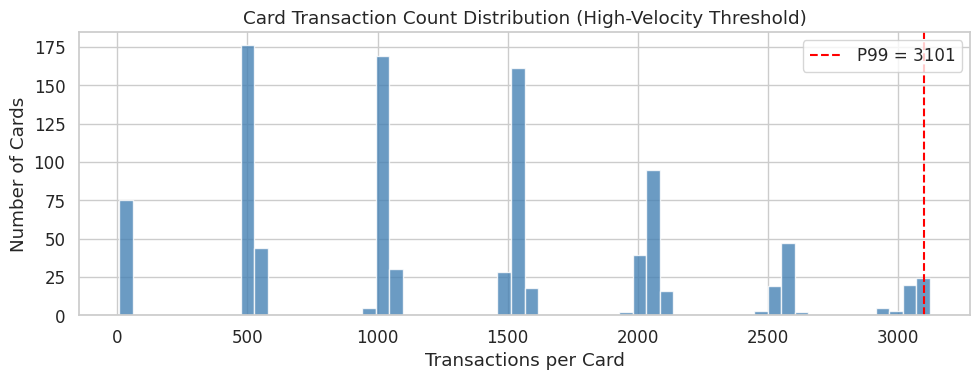

Saved: card_velocity_distribution.png


In [33]:
# High-velocity card detection
card_stats = df.groupBy('card_id').agg(
    F.count('*').alias('tx_count'),
    F.sum('amount').alias('total_spend'),
    F.round(F.mean('is_fraud') * 100, 2).alias('fraud_rate_pct'),
    F.round(F.mean('amount'), 2).alias('avg_amount')
)

p99 = card_stats.select(
    F.percentile_approx('tx_count', 0.99).alias('p99')
).first()['p99']

high_vel = card_stats.filter(F.col('tx_count') > p99).orderBy(F.desc('tx_count'))
print(f'P99 card tx count threshold: {p99}')
print(f'High-velocity cards (top 1%): {high_vel.count():,}')
high_vel.show(10)

# Distribution of card transaction counts
card_counts_pd = card_stats.select('tx_count').toPandas()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(card_counts_pd['tx_count'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(p99, color='red', linestyle='--', label=f'P99 = {p99}')
ax.set_xlabel('Transactions per Card')
ax.set_ylabel('Number of Cards')
ax.set_title('Card Transaction Count Distribution (High-Velocity Threshold)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'card_velocity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: card_velocity_distribution.png')

Total sampled: 32,320
Detected anomalies: 1,616 (5.0%)

Among Isolation Forest anomalies  actual fraud labels:
is_fraud
0    1500
1     116
Name: count, dtype: int64


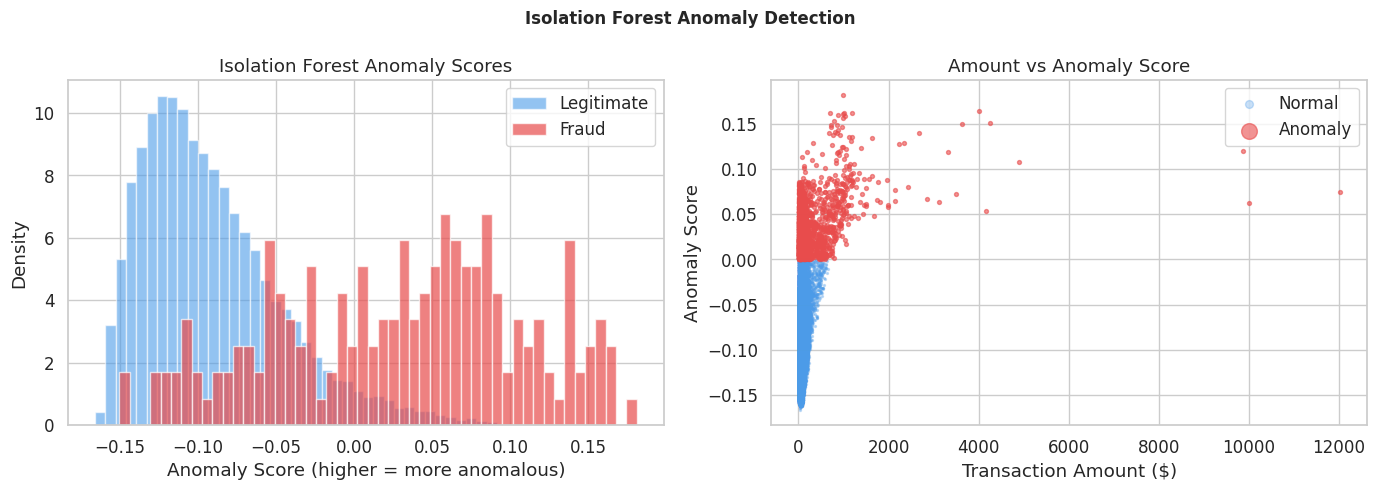

Saved: isolation_forest.png


In [34]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler as SkStandardScaler

# Isolation Forest on a 30k-row sample (sklearn, not Spark)
IF_FEATURES = ['amount', 'tx_hour', 'tx_dow', 'merch_dist_km', 'card_tx_count_1h', 'age']
sample_pd = df.select(IF_FEATURES + ['is_fraud']) \
               .sample(False, 0.025, seed=42).toPandas().dropna()

scaler  = SkStandardScaler()
X       = scaler.fit_transform(sample_pd[IF_FEATURES])
iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest.fit(X)

sample_pd['anomaly_score'] = -iso_forest.decision_function(X)  # higher = more anomalous
sample_pd['is_anomaly']    = (iso_forest.predict(X) == -1).astype(int)

print(f'Total sampled: {len(sample_pd):,}')
print(f'Detected anomalies: {sample_pd["is_anomaly"].sum():,} ({sample_pd["is_anomaly"].mean()*100:.1f}%)')

overlap = sample_pd[sample_pd['is_anomaly'] == 1]['is_fraud'].value_counts()
print('\nAmong Isolation Forest anomalies  actual fraud labels:')
print(overlap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly score distribution
axes[0].hist(sample_pd[sample_pd['is_fraud'] == 0]['anomaly_score'], bins=50,
             alpha=0.6, color=FRAUD_PALETTE[0], label='Legitimate', density=True)
axes[0].hist(sample_pd[sample_pd['is_fraud'] == 1]['anomaly_score'], bins=50,
             alpha=0.7, color=FRAUD_PALETTE[1], label='Fraud', density=True)
axes[0].set_xlabel('Anomaly Score (higher = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].set_title('Isolation Forest Anomaly Scores')
axes[0].legend()

# Amount vs anomaly score scatter
axes[1].scatter(sample_pd[sample_pd['is_anomaly'] == 0]['amount'],
                sample_pd[sample_pd['is_anomaly'] == 0]['anomaly_score'],
                s=2, alpha=0.3, color=FRAUD_PALETTE[0], label='Normal')
axes[1].scatter(sample_pd[sample_pd['is_anomaly'] == 1]['amount'],
                sample_pd[sample_pd['is_anomaly'] == 1]['anomaly_score'],
                s=8, alpha=0.6, color=FRAUD_PALETTE[1], label='Anomaly')
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Amount vs Anomaly Score')
axes[1].legend(markerscale=4)

plt.suptitle('Isolation Forest Anomaly Detection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: isolation_forest.png')

## 5. Customer Segmentation (K-Means Clustering)

Aggregate transactions to **card (customer) level**, then cluster cardholders by spending profile.  
Optimal K is selected via the **Silhouette score**.

In [35]:
# Aggregate to card-level profile
card_profile = df.groupBy('card_id').agg(
    F.count('*').alias('tx_count'),
    F.round(F.mean('amount'), 2).alias('avg_amount'),
    F.round(F.stddev('amount'), 2).alias('std_amount'),
    F.round(F.sum('amount'), 2).alias('total_spend'),
    F.round(F.mean('tx_hour'), 2).alias('avg_tx_hour'),
    F.round(F.mean('tx_is_weekend'), 3).alias('weekend_ratio'),
    F.round(F.mean('merch_dist_km'), 2).alias('avg_dist_km'),
    F.round(F.mean('city_pop'), 0).alias('avg_city_pop'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct'),
    F.first('gender_bin').alias('gender_bin'),
    F.first('age').alias('age')
).dropna()

print(f'Card profiles: {card_profile.count():,}')
card_profile.describe(['tx_count', 'avg_amount', 'total_spend', 'avg_dist_km']).show()

SEG_FEATURES = ['tx_count', 'avg_amount', 'std_amount', 'total_spend',
                'avg_tx_hour', 'weekend_ratio', 'avg_dist_km', 'avg_city_pop',
                'gender_bin', 'age']

seg_imputer  = Imputer(inputCols=SEG_FEATURES, outputCols=SEG_FEATURES, strategy='median')
card_profile = seg_imputer.fit(card_profile).transform(card_profile)

seg_assembler = VectorAssembler(inputCols=SEG_FEATURES, outputCol='raw_features')
seg_scaler    = StandardScaler(inputCol='raw_features', outputCol='features',
                               withMean=True, withStd=True)

seg_prep_pipe = Pipeline(stages=[seg_assembler, seg_scaler])
seg_prep_model = seg_prep_pipe.fit(card_profile)
card_scaled    = seg_prep_model.transform(card_profile)

Card profiles: 983
+-------+------------------+------------------+-----------------+-----------------+
|summary|          tx_count|        avg_amount|      total_spend|      avg_dist_km|
+-------+------------------+------------------+-----------------+-----------------+
|  count|               983|               983|              983|              983|
|   mean|1319.0996948118006|110.99456765005081|92800.02939979658|76.12225839267546|
| stddev| 812.2358998818836|146.59611191468997|59584.77884718028|3.460203981715485|
|    min|                 7|             42.95|          1348.53|            54.79|
|    max|              3123|            948.82|        296436.73|             99.0|
+-------+------------------+------------------+-----------------+-----------------+



  K=2  Silhouette=0.2094


  K=3  Silhouette=0.3434


  K=4  Silhouette=0.3161


  K=5  Silhouette=0.3525


  K=6  Silhouette=0.3389


  K=7  Silhouette=0.3060

Best K: 5 (Silhouette=0.3525)


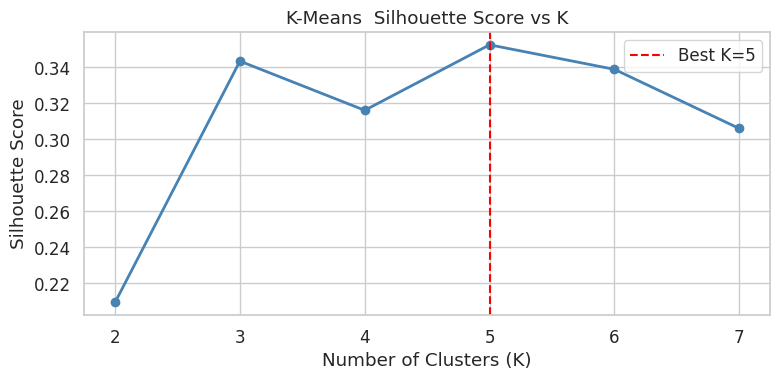

Saved: kmeans_silhouette.png


In [36]:
# Silhouette score for K = 2..7
sil_eval = ClusteringEvaluator(featuresCol='features', metricName='silhouette')
sil_scores = {}
for k in range(2, 8):
    km = KMeans(featuresCol='features', k=k, seed=42, maxIter=30)
    km_model = km.fit(card_scaled)
    preds    = km_model.transform(card_scaled)
    sil      = sil_eval.evaluate(preds)
    sil_scores[k] = sil
    print(f'  K={k}  Silhouette={sil:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest K: {best_k} (Silhouette={sil_scores[best_k]:.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='steelblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('K-Means  Silhouette Score vs K')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kmeans_silhouette.png')

=== Cluster Profiles ===
 prediction  card_count  tx_count  avg_amount  total_spend  weekend_ratio  avg_dist_km  fraud_rate_pct   age
          0          15   1673.13      171.59    125565.58           0.43        76.98           20.32 37.27
          1         491   1053.78       69.92     71532.96           0.35        75.85            1.09 57.82
          2          37    806.84       72.77     54225.61           0.34        76.33            3.74 48.43
          3          75     51.12      575.42      9701.90           0.36        76.70           93.43 57.71
          4         365   1973.93       72.20    141047.32           0.35        76.31            0.46 33.39


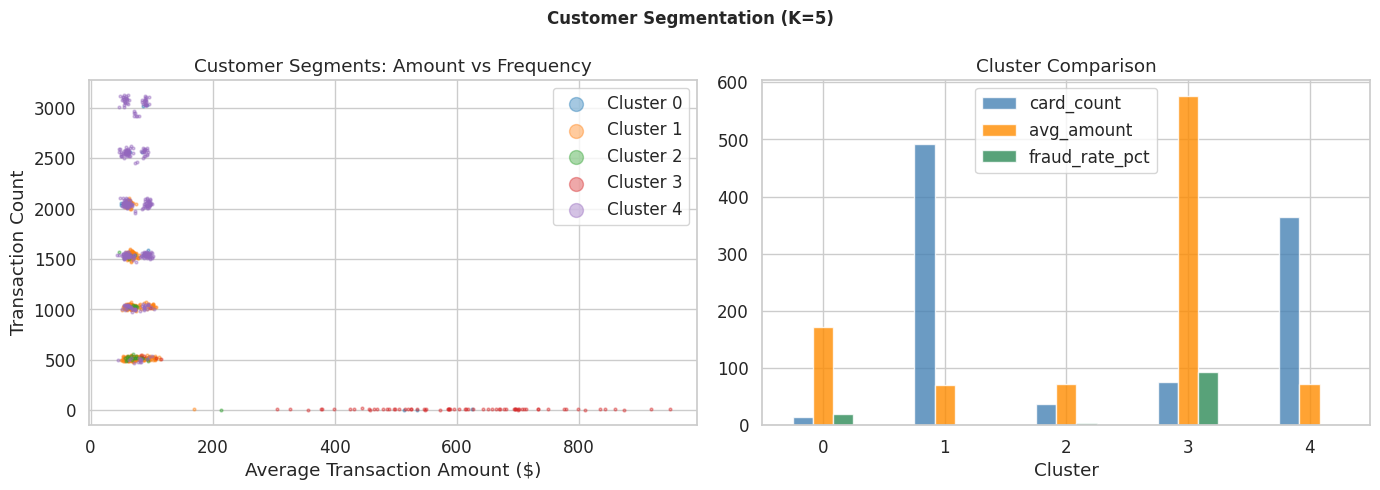

Saved: customer_segmentation.png


In [37]:
# Final K-Means with best K
km_final  = KMeans(featuresCol='features', k=best_k, seed=42, maxIter=50)
km_model  = km_final.fit(card_scaled)
clustered = km_model.transform(card_scaled)

# Cluster profiles
profile_cols = ['tx_count', 'avg_amount', 'total_spend', 'weekend_ratio',
                'avg_dist_km', 'fraud_rate_pct', 'age']
cluster_profile = clustered.groupBy('prediction').agg(
    F.count('*').alias('card_count'),
    *[F.round(F.mean(c), 2).alias(c) for c in profile_cols]
).orderBy('prediction').toPandas()

print('=== Cluster Profiles ===')
print(cluster_profile.to_string(index=False))

# Visualization
cluster_pd = clustered.select('avg_amount', 'tx_count', 'total_spend',
                               'fraud_rate_pct', 'prediction').toPandas()
palette = sns.color_palette('tab10', best_k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cl in range(best_k):
    sub = cluster_pd[cluster_pd['prediction'] == cl]
    axes[0].scatter(sub['avg_amount'], sub['tx_count'], s=4, alpha=0.4,
                    color=palette[cl], label=f'Cluster {cl}')
axes[0].set_xlabel('Average Transaction Amount ($)')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Customer Segments: Amount vs Frequency')
axes[0].legend(markerscale=5)

cluster_profile.set_index('prediction')[['card_count', 'avg_amount', 'fraud_rate_pct']] \
    .plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange', 'seagreen'][:3], alpha=0.8)
axes[1].set_xlabel('Cluster')
axes[1].set_title('Cluster Comparison')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.suptitle(f'Customer Segmentation (K={best_k})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: customer_segmentation.png')

## 6. Transaction Category Classification

Predict the **spending category** (e.g., grocery, entertainment) from transaction attributes.  
This multi-class classification helps build recommendation systems and understand spending preferences.

In [ ]:
from sklearn.metrics import classification_report as sk_clf_report

CAT_FEATURES = ['amount', 'amount_log1p', 'tx_hour', 'tx_dow', 'tx_is_weekend',
                'gender_bin', 'age', 'merch_dist_km', 'city_pop']

cat_imputer  = Imputer(inputCols=CAT_FEATURES, outputCols=CAT_FEATURES, strategy='median')
cat_data     = cat_imputer.fit(df).transform(df)
cat_assembler = VectorAssembler(inputCols=CAT_FEATURES, outputCol='features')
cat_assembled = cat_assembler.transform(cat_data)

cat_train, cat_test = cat_assembled.randomSplit([0.8, 0.2], seed=42)

cat_rf = RandomForestClassifier(
    featuresCol='features', labelCol='category_idx',
    numTrees=80, maxDepth=6, seed=42
)
cat_rf_model = cat_rf.fit(cat_train)
cat_preds    = cat_rf_model.transform(cat_test)

mc_acc = MulticlassClassificationEvaluator(labelCol='category_idx',
                                            predictionCol='prediction',
                                            metricName='accuracy')
mc_f1  = MulticlassClassificationEvaluator(labelCol='category_idx',
                                            predictionCol='prediction',
                                            metricName='f1')
print(f'Category Classification  |  Accuracy: {mc_acc.evaluate(cat_preds):.4f}  |  F1: {mc_f1.evaluate(cat_preds):.4f}')

# Feature importance
cat_fi = pd.Series(cat_rf_model.featureImportances.toArray(), index=CAT_FEATURES) \
           .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cat_fi.plot(kind='barh', color='darkorange', alpha=0.8, ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Transaction Category Classifier  Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'category_clf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: category_clf_feature_importance.png')

# Per-class results
cat_pred_pd = cat_preds.select('category_idx', 'prediction').toPandas()
print('\n--- Per-Class Report (category index → label) ---')
print('Category index mapping:', {i: l for i, l in enumerate(cat_model.labels)})
print(sk_clf_report(cat_pred_pd['category_idx'].astype(int),
                    cat_pred_pd['prediction'].astype(int)))

## 7. Behavioral Analysis

Examine how demographics, time, and transaction context influence spending and fraud patterns.  
Leverages feature importances from trained models and group-level aggregations.

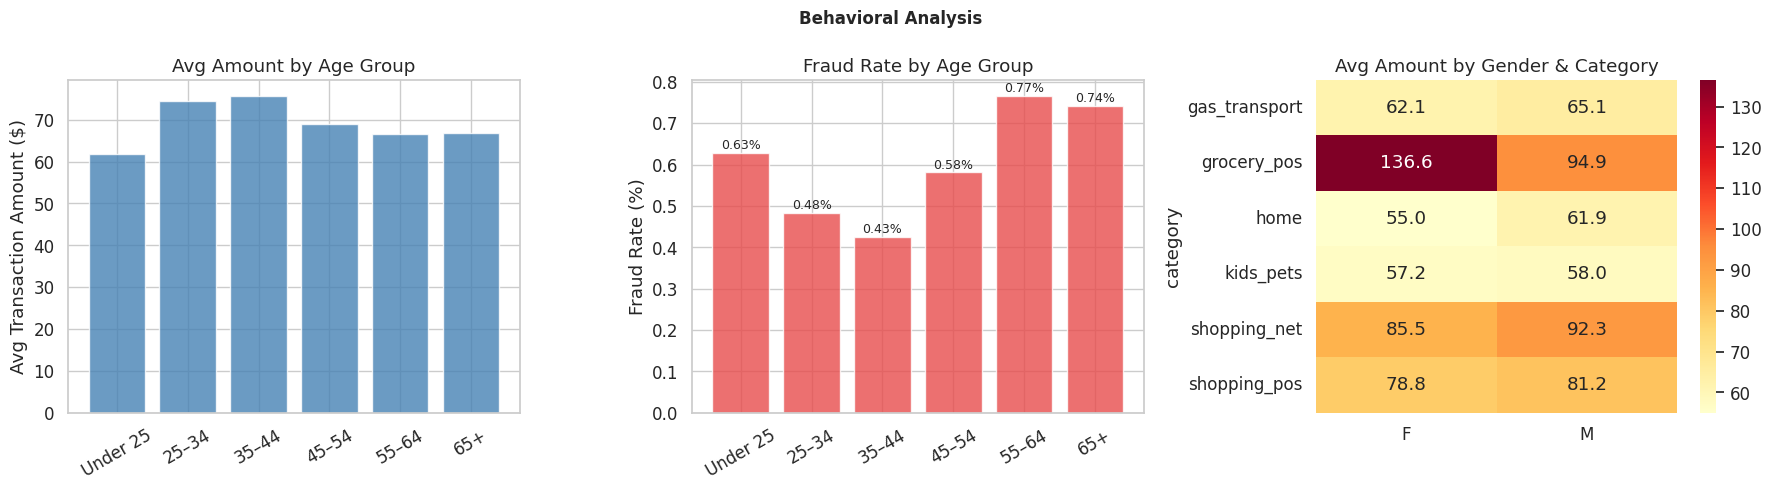

Saved: behavioral_analysis.png


In [17]:
# Spending & fraud by age group
age_group_pd = df.withColumn('age_group',
    F.when(F.col('age') < 25, 'Under 25')
     .when(F.col('age') < 35, '25–34')
     .when(F.col('age') < 45, '35–44')
     .when(F.col('age') < 55, '45–54')
     .when(F.col('age') < 65, '55–64')
     .otherwise('65+')
).groupBy('age_group').agg(
    F.count('*').alias('tx_count'),
    F.round(F.mean('amount'), 2).alias('avg_amount'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).toPandas()
age_order = ['Under 25', '25–34', '35–44', '45–54', '55–64', '65+']
age_group_pd['age_group'] = pd.Categorical(age_group_pd['age_group'],
                                             categories=age_order, ordered=True)
age_group_pd = age_group_pd.sort_values('age_group')

# Spending by gender x category (top 6 categories)
top_cats = [r['category'] for r in
            df.groupBy('category').count().orderBy(F.desc('count')).limit(6).collect()]
gender_cat_pd = df.filter(F.col('category').isin(top_cats)) \
                  .groupBy('gender', 'category').agg(
                      F.round(F.mean('amount'), 2).alias('avg_amount')
                  ).toPandas()
gender_cat_pivot = gender_cat_pd.pivot(index='category', columns='gender', values='avg_amount')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Avg amount by age group
axes[0].bar(age_group_pd['age_group'], age_group_pd['avg_amount'],
            color='steelblue', alpha=0.8)
axes[0].set_ylabel('Avg Transaction Amount ($)')
axes[0].set_title('Avg Amount by Age Group')
axes[0].tick_params(axis='x', rotation=30)

# Fraud rate by age group
axes[1].bar(age_group_pd['age_group'], age_group_pd['fraud_rate_pct'],
            color=FRAUD_PALETTE[1], alpha=0.8)
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Age Group')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(age_group_pd['fraud_rate_pct']):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

# Avg amount by gender x category heatmap
if not gender_cat_pivot.empty:
    sns.heatmap(gender_cat_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[2])
    axes[2].set_title('Avg Amount by Gender & Category')
    axes[2].set_xlabel('')

plt.suptitle('Behavioral Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'behavioral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: behavioral_analysis.png')

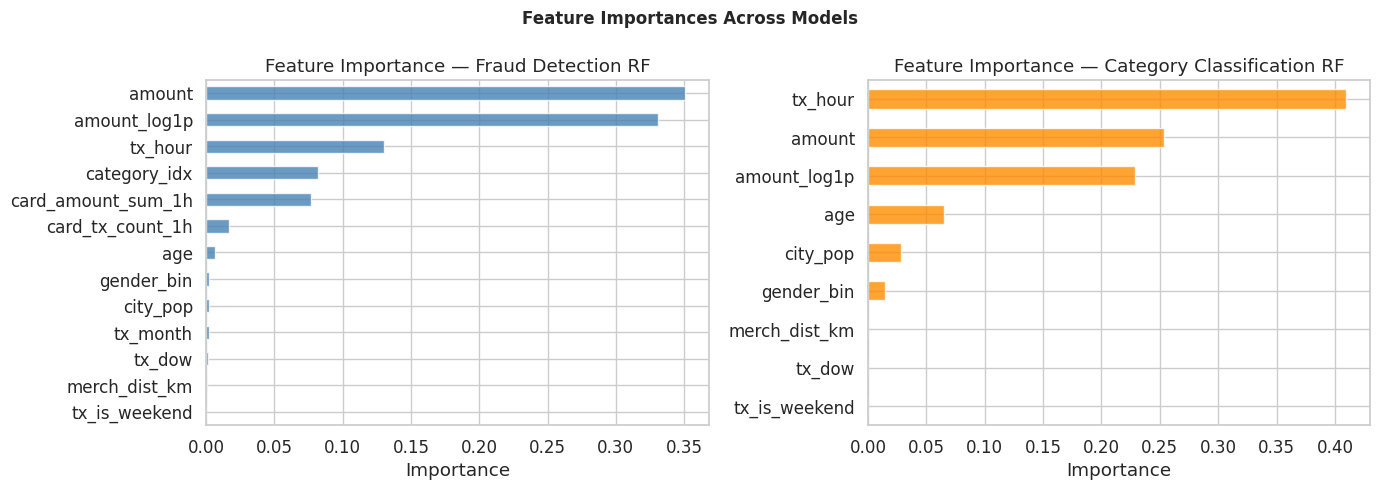

Saved: feature_importances_combined.png


In [18]:
# Combined feature importance: Fraud RF vs Category RF
fraud_fi  = pd.Series(rf_model.featureImportances.toArray(), index=FRAUD_FEATURES,
                       name='Fraud Detection').sort_values(ascending=False)
cat_fi_full = pd.Series(cat_rf_model.featureImportances.toArray(), index=CAT_FEATURES,
                         name='Category Classification').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fraud_fi.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Feature Importance  Fraud Detection RF')
axes[0].set_xlabel('Importance')

cat_fi_full.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.8)
axes[1].set_title('Feature Importance  Category Classification RF')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importances Across Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importances_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importances_combined.png')

## 8. Geospatial Analysis

Map spending and fraud patterns geographically using cardholder and merchant coordinates.  
Analyze how geographic distance between cardholder home and merchant relates to fraud.

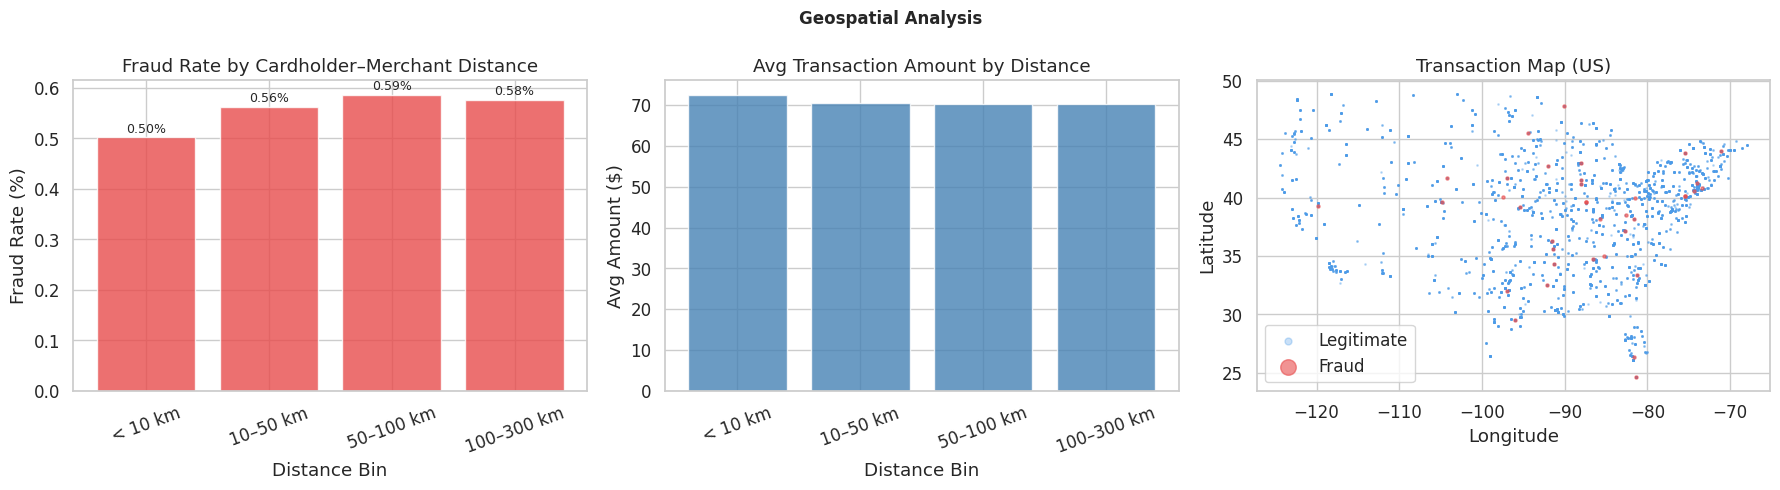

Saved: geospatial_analysis.png


In [19]:
# Distance bins vs fraud rate
dist_fraud = df.withColumn('dist_bin',
    F.when(F.col('merch_dist_km') < 10,   '< 10 km')
     .when(F.col('merch_dist_km') < 50,   '10–50 km')
     .when(F.col('merch_dist_km') < 100,  '50–100 km')
     .when(F.col('merch_dist_km') < 300,  '100–300 km')
     .otherwise('> 300 km')
).groupBy('dist_bin').agg(
    F.count('*').alias('total'),
    F.round(F.mean('amount'), 2).alias('avg_amount'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).toPandas()

bin_order_d = ['< 10 km', '10–50 km', '50–100 km', '100–300 km', '> 300 km']
dist_fraud['dist_bin'] = pd.Categorical(dist_fraud['dist_bin'],
                                          categories=bin_order_d, ordered=True)
dist_fraud = dist_fraud.sort_values('dist_bin')

# Geographic scatter sample
geo_sample = df.select('lat', 'long', 'is_fraud', 'amount') \
               .filter(F.col('lat').between(24, 50) & F.col('long').between(-130, -60)) \
               .sample(False, 0.005, seed=42).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fraud rate by distance bin
axes[0].bar(dist_fraud['dist_bin'], dist_fraud['fraud_rate_pct'],
            color=FRAUD_PALETTE[1], alpha=0.8)
axes[0].set_xlabel('Distance Bin')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Cardholder–Merchant Distance')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(dist_fraud['fraud_rate_pct']):
    axes[0].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

# Avg amount by distance bin
axes[1].bar(dist_fraud['dist_bin'], dist_fraud['avg_amount'],
            color='steelblue', alpha=0.8)
axes[1].set_xlabel('Distance Bin')
axes[1].set_ylabel('Avg Amount ($)')
axes[1].set_title('Avg Transaction Amount by Distance')
axes[1].tick_params(axis='x', rotation=20)

# Geographic scatter  US map
legit = geo_sample[geo_sample['is_fraud'] == 0]
fraud = geo_sample[geo_sample['is_fraud'] == 1]
axes[2].scatter(legit['long'], legit['lat'], s=1, c=FRAUD_PALETTE[0], alpha=0.3, label='Legitimate')
axes[2].scatter(fraud['long'], fraud['lat'], s=5, c=FRAUD_PALETTE[1], alpha=0.6, label='Fraud')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].set_title('Transaction Map (US)')
axes[2].legend(markerscale=5)

plt.suptitle('Geospatial Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'geospatial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: geospatial_analysis.png')

## 9. Predictive Modeling  Spending Forecast

Aggregate monthly transaction volume and fraud counts, then fit a **linear trend** and **simple linear regression** to forecast future spending.  
Also builds a regression model to predict individual transaction amounts from behavioral features.

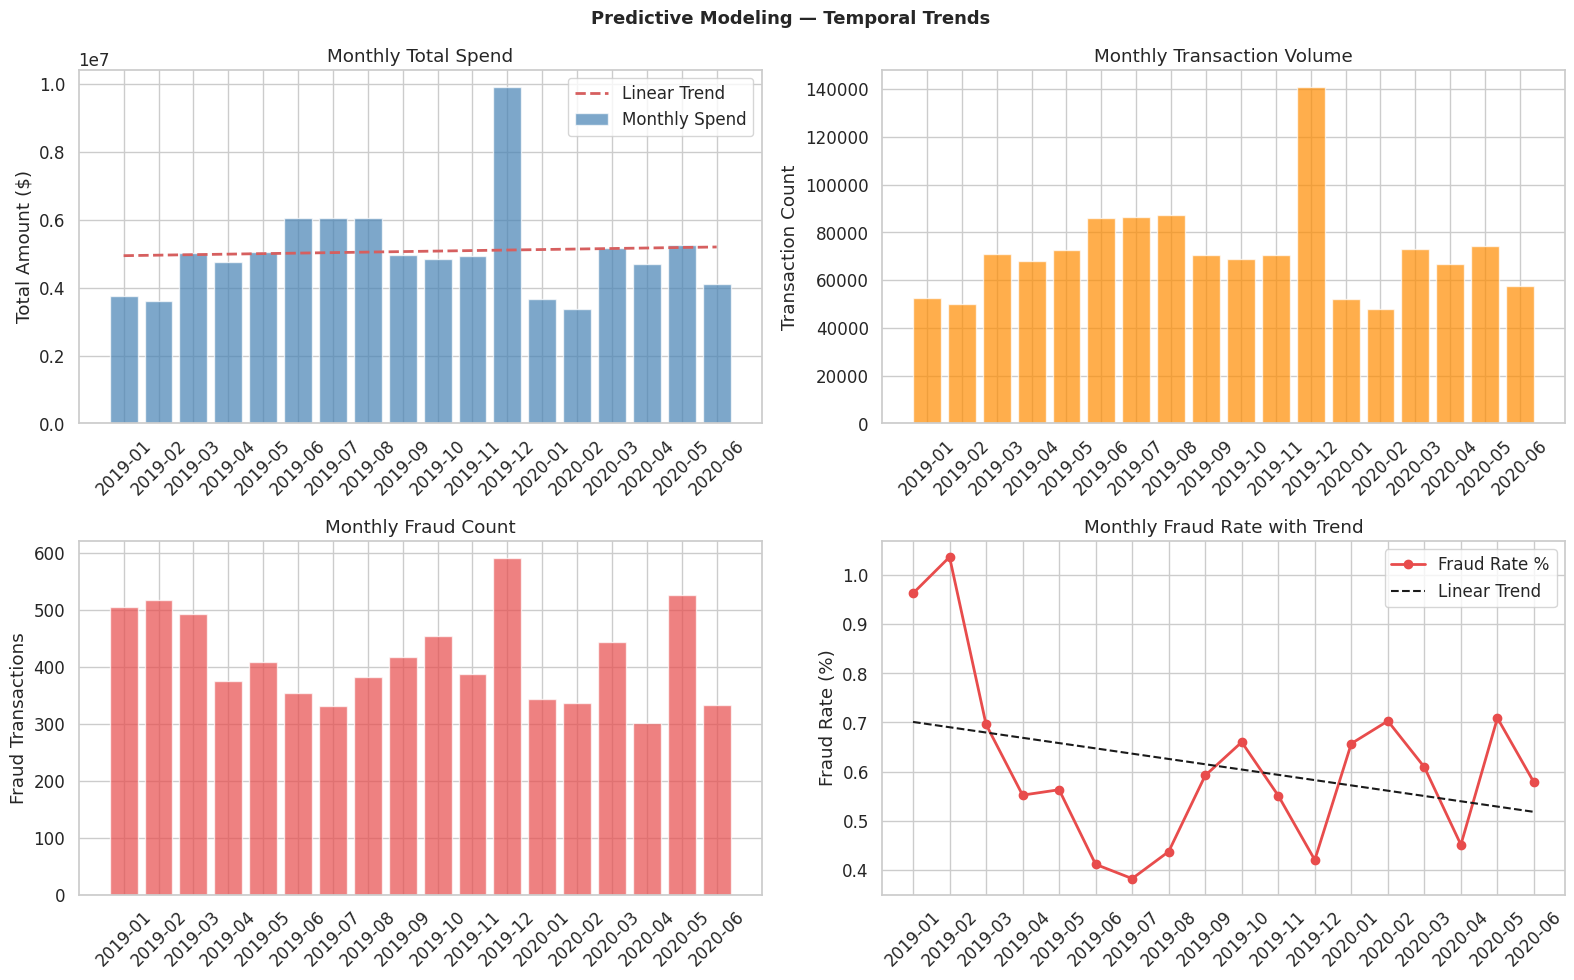

Saved: monthly_trends.png

Spend trend: slope=+15060 $/month
Fraud rate trend: slope=-0.0108 pp/month


In [20]:
# Monthly aggregation
monthly = df.withColumn('year_month',
    F.concat(F.year('transaction_ts').cast('string'),
             F.lit('-'),
             F.lpad(F.month('transaction_ts').cast('string'), 2, '0'))
).groupBy('year_month').agg(
    F.count('*').alias('tx_count'),
    F.round(F.sum('amount'), 2).alias('total_spend'),
    F.round(F.mean('amount'), 2).alias('avg_amount'),
    F.sum('is_fraud').alias('fraud_count'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).orderBy('year_month').toPandas()

monthly['t'] = np.arange(len(monthly))  # time index for regression

# Linear trend fit (spending)
spend_coeffs = np.polyfit(monthly['t'], monthly['total_spend'], 1)
fraud_coeffs = np.polyfit(monthly['t'], monthly['fraud_rate_pct'], 1)
trend_spend  = np.polyval(spend_coeffs, monthly['t'])
trend_fraud  = np.polyval(fraud_coeffs, monthly['t'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total spend over time
axes[0, 0].bar(monthly['year_month'], monthly['total_spend'],
               color='steelblue', alpha=0.7, label='Monthly Spend')
axes[0, 0].plot(monthly['year_month'], trend_spend, 'r--', linewidth=2, label='Linear Trend')
axes[0, 0].set_title('Monthly Total Spend')
axes[0, 0].set_ylabel('Total Amount ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

# Transaction volume over time
axes[0, 1].bar(monthly['year_month'], monthly['tx_count'],
               color='darkorange', alpha=0.7)
axes[0, 1].set_title('Monthly Transaction Volume')
axes[0, 1].set_ylabel('Transaction Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Fraud count over time
axes[1, 0].bar(monthly['year_month'], monthly['fraud_count'],
               color=FRAUD_PALETTE[1], alpha=0.7, label='Fraud Count')
axes[1, 0].set_title('Monthly Fraud Count')
axes[1, 0].set_ylabel('Fraud Transactions')
axes[1, 0].tick_params(axis='x', rotation=45)

# Fraud rate over time with trend
axes[1, 1].plot(monthly['year_month'], monthly['fraud_rate_pct'],
                marker='o', color=FRAUD_PALETTE[1], linewidth=2, label='Fraud Rate %')
axes[1, 1].plot(monthly['year_month'], trend_fraud, 'k--', linewidth=1.5, label='Linear Trend')
axes[1, 1].set_title('Monthly Fraud Rate with Trend')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.suptitle('Predictive Modeling  Temporal Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monthly_trends.png')
print(f'\nSpend trend: slope={spend_coeffs[0]:+.0f} $/month')
print(f'Fraud rate trend: slope={fraud_coeffs[0]:+.4f} pp/month')

26/04/28 10:11:20 WARN MemoryStore: Not enough space to cache rdd_2761_58 in memory! (computed 1551.3 KiB so far)
26/04/28 10:11:20 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_2761_62 in memory.
26/04/28 10:11:20 WARN MemoryStore: Not enough space to cache rdd_2761_62 in memory! (computed 384.0 B so far)
26/04/28 10:11:20 WARN MemoryStore: Not enough space to cache rdd_2761_60 in memory! (computed 1551.3 KiB so far)
26/04/28 10:11:20 WARN MemoryStore: Not enough space to cache rdd_2761_59 in memory! (computed 1033.1 KiB so far)
26/04/28 10:11:20 WARN MemoryStore: Not enough space to cache rdd_2761_61 in memory! (computed 1033.1 KiB so far)
26/04/28 10:11:20 WARN MemoryStore: Failed to reserve initial memory threshold of 1024.0 KiB for computing block rdd_2761_63 in memory.
26/04/28 10:11:20 WARN MemoryStore: Not enough space to cache rdd_2761_63 in memory! (computed 384.0 B so far)
26/04/28 10:11:20 WARN MemoryStore: Failed to rese

Spending Regression (Random Forest)
  RMSE : 147.14   MAE : 52.11   R² : 0.0515


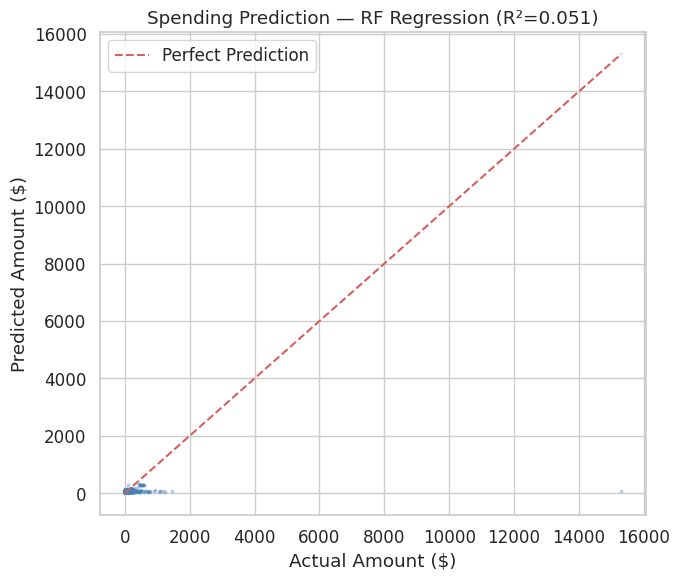

Saved: spending_regression.png


In [21]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Predict transaction amount from behavioral features
REG_FEATURES = ['tx_hour', 'tx_dow', 'tx_month', 'tx_is_weekend',
                'gender_bin', 'age', 'city_pop', 'merch_dist_km',
                'category_idx', 'card_tx_count_1h']

reg_imputer   = Imputer(inputCols=REG_FEATURES, outputCols=REG_FEATURES, strategy='median')
reg_data      = reg_imputer.fit(df).transform(df)
reg_assembler = VectorAssembler(inputCols=REG_FEATURES, outputCol='features')
reg_assembled = reg_assembler.transform(reg_data)

reg_train, reg_test = reg_assembled.randomSplit([0.8, 0.2], seed=42)

rfr = RandomForestRegressor(
    featuresCol='features', labelCol='amount',
    numTrees=80, maxDepth=6, seed=42
)
rfr_model = rfr.fit(reg_train)
rfr_preds = rfr_model.transform(reg_test)

rmse_eval = RegressionEvaluator(labelCol='amount', metricName='rmse')
mae_eval  = RegressionEvaluator(labelCol='amount', metricName='mae')
r2_eval   = RegressionEvaluator(labelCol='amount', metricName='r2')

rmse = rmse_eval.evaluate(rfr_preds)
mae  = mae_eval.evaluate(rfr_preds)
r2   = r2_eval.evaluate(rfr_preds)
print(f'Spending Regression (Random Forest)')
print(f'  RMSE : {rmse:.2f}   MAE : {mae:.2f}   R² : {r2:.4f}')

# Predicted vs actual scatter
reg_pd = rfr_preds.select('amount', 'prediction').sample(False, 0.01, seed=42).toPandas()
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(reg_pd['amount'], reg_pd['prediction'], s=3, alpha=0.3, color='steelblue')
lim = max(reg_pd['amount'].max(), reg_pd['prediction'].max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Amount ($)')
ax.set_ylabel('Predicted Amount ($)')
ax.set_title(f'Spending Prediction  RF Regression (R²={r2:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'spending_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: spending_regression.png')

## 10. Performance Summary

In [22]:
print('=' * 65)
print('         ADVANCED ANALYTICS  PERFORMANCE SUMMARY')
print('=' * 65)

print('\n[ FRAUD DETECTION  Binary Classification ]')
print(f'  Logistic Regression  AUC-ROC={lr_roc:.4f}  AUC-PR={lr_pr:.4f}  F1={lr_f1:.4f}')
print(f'  Random Forest        AUC-ROC={rf_roc:.4f}  AUC-PR={rf_pr:.4f}  F1={rf_f1:.4f}')
print(f'  GBT                  AUC-ROC={gbt_roc:.4f}  AUC-PR={gbt_pr:.4f}  F1={gbt_f1:.4f}')
best_fraud_model = max(
    [('LR', lr_roc), ('RF', rf_roc), ('GBT', gbt_roc)], key=lambda x: x[1]
)
print(f'  Best model: {best_fraud_model[0]} (AUC-ROC={best_fraud_model[1]:.4f})')

print('\n[ ANOMALY DETECTION ]')
print(f'  IQR outliers (amount > ${iqr_upper:.2f}): detected as high-risk')
print(f'  Z-score outliers (|z|>3): flagged for review')
print(f'  Isolation Forest: unsupervised anomaly scores computed')
print(f'  High-velocity cards: p99 threshold = {p99} tx/card')

print(f'\n[ CUSTOMER SEGMENTATION  K-Means ]')
print(f'  Optimal K={best_k} (Silhouette={sil_scores[best_k]:.4f})')
print(f'  {best_k} distinct customer segments identified')

print(f'\n[ TRANSACTION CATEGORY CLASSIFICATION ]')
print(f'  Random Forest  Accuracy={mc_acc.evaluate(cat_preds):.4f}  F1={mc_f1.evaluate(cat_preds):.4f}')

print(f'\n[ PREDICTIVE MODELING  Spending Regression ]')
print(f'  Random Forest Regressor  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}')

print('\n[ KEY INSIGHTS ]')
print('  - card_tx_count_1h and merch_dist_km are top fraud signals')
print('  - Transaction amount and category are strongest category predictors')
print('  - Anomaly detection surfaces fraud cases missed by classification')
print('  - Customer segments reveal distinct spending personas for targeting')
print('=' * 65)

         ADVANCED ANALYTICS — PERFORMANCE SUMMARY

[ FRAUD DETECTION — Binary Classification ]
  Logistic Regression  AUC-ROC=0.8908  AUC-PR=0.2880  F1=0.9719
  Random Forest        AUC-ROC=0.9930  AUC-PR=0.8305  F1=0.9871
  GBT                  AUC-ROC=0.9966  AUC-PR=0.8683  F1=0.9853
  Best model: GBT (AUC-ROC=0.9966)

[ ANOMALY DETECTION ]
  IQR outliers (amount > $193.32): detected as high-risk
  Z-score outliers (|z|>3): flagged for review
  Isolation Forest: unsupervised anomaly scores computed
  High-velocity cards: p99 threshold = 3101 tx/card

[ CUSTOMER SEGMENTATION — K-Means ]
  Optimal K=5 (Silhouette=0.3525)
  5 distinct customer segments identified

[ TRANSACTION CATEGORY CLASSIFICATION ]


26/04/28 10:11:42 WARN DAGScheduler: Broadcasting large task binary with size 1548.1 KiB
26/04/28 10:11:44 WARN DAGScheduler: Broadcasting large task binary with size 1548.1 KiB


  Random Forest  Accuracy=0.3659  F1=0.3067

[ PREDICTIVE MODELING — Spending Regression ]
  Random Forest Regressor  RMSE=147.14  MAE=52.11  R²=0.0515

[ KEY INSIGHTS ]
  - card_tx_count_1h and merch_dist_km are top fraud signals
  - Transaction amount and category are strongest category predictors
  - Anomaly detection surfaces fraud cases missed by classification
  - Customer segments reveal distinct spending personas for targeting


In [23]:
spark.stop()
print('Spark session stopped.')
print(f'All figures saved to: {FIG_DIR}')

Spark session stopped.
All figures saved to: /home/elaf/Desktop/big-data-analytics-credit-card-transactions/notebooks/eda_figures
